# DMD hotspot-sign analysis

This notebook uses the repository's DMD search analysis to:

1. Visually validate hotspot traces and sign calculations for a selected animal/cell.
2. Collect final-depth hotspots from searches held near −35 mV.
3. Compare hotspot-sign distributions across random, reward, and punish groups.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import numpy as np
import pandas as pd

import pyNeuroDAP as ndap


/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def vhold_color(v):
    if v <= -50:   # ~ -70 mV
        return "tab:red"
    if v >= 0:     # ~ +10 mV
        return "tab:blue"
    return "tab:purple"  # ~ -35 mV

## Configuration

`RESULTS_ROOT` contains one folder per animal. `ANIMALS_TO_LOAD` controls which animals enter the reusable cache, independently of their group assignments. The newest `Results-*` folder containing a `cells_DMD_*.mat` table is used for each animal. `MIN_FINAL_DEPTH` is an inclusive post-loading cutoff for the stored depth of the repeated final-depth hotspot search; set it to `None` to disable depth filtering. After the cache has been built once, group lists and `MIN_FINAL_DEPTH` can be changed without reloading the MATLAB files.


In [3]:
RESULTS_ROOT = Path(
    "/Volumes/Neurobio/MICROSCOPE/Shun/Project valence/Patch/from_DC_PLOM"
)
TARGET_VHOLD_MV = -35.0
VHOLD_TOLERANCE_MV = 3.0
MIN_FINAL_DEPTH = 3  # Inclusive cutoff; set to None to keep every depth.
MIN_SWEEPS_PER_HOTSPOT = 2
PLOT_WINDOW_MS = (-10.0, 50.0)

GROUP_COLORS = {
    "random": "tab:gray",
    "reward": "tab:green",
    "punish": "tab:purple",
}

In [4]:
# These assignments are applied later to the in-memory cache.
random_animals = ["SL458", "SL452"]
reward_animals = ["SL468", "SL456", "SL455"]
punish_animals = ["SL469", "SL457", "SL454", "SL453", "SL448"]

ANIMALS_TO_LOAD = list(
    dict.fromkeys(random_animals + reward_animals + punish_animals)
)

## Shared analysis helpers

The accuracy check and group analysis below share these functions, so hotspot selection, extrema, and sign calculations are identical in both paths.

In [5]:
# Data discovery, loading, and repeated-search selection

HOTSPOT_COLUMNS = [
    "group", "animal", "results_folder", "cell", "search_idx",
    "search_name", "vhold_mv", "final_depth", "spot_order", "spot_idx",
    "spot_row", "spot_col", "n_sweeps", "max_current_pa", "min_current_pa",
    "hotspot_sign",
]
LOG_COLUMNS = [
    "group", "animal", "results_folder", "cell", "search_idx",
    "final_depth", "status", "n_hotspots",
]


def as_numeric_vector(value):
    """Flatten a MATLAB-derived nested value into a numeric vector."""
    values = []

    def visit(item):
        if isinstance(item, (list, tuple, np.ndarray)):
            for child in np.asarray(item, dtype=object).ravel():
                visit(child)
        elif item is not None:
            values.append(float(item))

    visit(value)
    return np.asarray(values, dtype=float)


def latest_results_entry(animal):
    """Return the newest Results-* folder containing a cells_DMD table."""
    entries = []
    for results_dir in sorted((RESULTS_ROOT / animal).glob("Results-*")):
        folder_index = ndap.index_results_folder(results_dir)
        if folder_index["cells_mat_path"] is not None:
            entries.append((results_dir, folder_index["cells_mat_path"]))
    if not entries:
        raise FileNotFoundError(
            f"No Results-* folder with cells_DMD_*.mat found for {animal}"
        )
    return entries[-1]


def load_animal_dataset(animal):
    """Load the newest analyzed DMD dataset for one animal."""
    results_dir, cells_mat_path = latest_results_entry(animal)
    print(f"Loading {animal}/{results_dir.name}")
    return {
        "animal": animal,
        "results_dir": results_dir,
        "cells_df": ndap.load_cells_table(cells_mat_path),
    }


def epoch_vhold_hint(search_name):
    """Infer the nominal holding voltage encoded in an epoch name."""
    tokens = str(search_name).lower().replace("-", "_").split("_")
    if "m35" in tokens:
        return -35.0
    if "exci" in tokens:
        return -70.0
    if "inhi" in tokens:
        return 10.0
    return None


def find_repeated_final_depth_searches(
    cell_row,
    target_mv=TARGET_VHOLD_MV,
    tolerance_mv=VHOLD_TOLERANCE_MV,
):
    """Find dedicated repeated final-depth hotspot searches near target_mv."""
    raw_vholds = as_numeric_vector(cell_row.get("Vhold"))
    epochs = cell_row.get("Epochs")
    epochs = list(epochs) if isinstance(epochs, (list, tuple, np.ndarray)) else []

    # Use measured Vhold only when it aligns one-to-one with Epochs.
    # Some MATLAB tables contain another numeric reference (for example,
    # spotSequence) in the loaded Vhold field. Epoch suffixes provide a
    # reliable fallback for the dedicated exci/inhi/m35 searches.
    vholds = np.full(len(epochs), np.nan, dtype=float)
    if len(raw_vholds) == len(epochs):
        vholds[:] = raw_vholds
    for search_idx, search_name in enumerate(epochs):
        hint = epoch_vhold_hint(search_name)
        if hint is not None and (
            not np.isfinite(vholds[search_idx])
            or not np.isclose(vholds[search_idx], hint, atol=15.0, rtol=0)
        ):
            vholds[search_idx] = hint

    max_depth_searches = []
    fallback_hotspot_searches = []

    for search_idx, search_name in enumerate(epochs):
        if not np.isclose(
            vholds[search_idx], target_mv, atol=tolerance_mv, rtol=0
        ):
            continue
        normalized_name = str(search_name).lower()
        if "hotspot" not in normalized_name:
            continue
        if "maxsearchdepth" in normalized_name:
            max_depth_searches.append(search_idx)
        else:
            fallback_hotspot_searches.append(search_idx)

    # maxSearchDepth is the repeated recording for the last/deepest map depth.
    # The fallback supports single-depth datasets that only use hotspot_m35.
    selected = max_depth_searches or fallback_hotspot_searches
    return vholds, epochs, np.asarray(selected, dtype=int)


In [6]:
# Repeated-sweep extraction and hotspot-sign calculation

def option_scalar(cell_row, key, default):
    """Read one scalar from the MATLAB Options structure."""
    options = cell_row.get("Options")
    if not isinstance(options, dict) or options.get(key) is None:
        return float(default)
    values = as_numeric_vector(options[key])
    return float(values[0]) if len(values) else float(default)


def repeated_search_depth(dataset, cell_id, search_idx):
    """Read the repeated search's final depth from its stored metadata."""
    cells_df = dataset["cells_df"]
    selected = cells_df[cells_df["Cell"] == int(cell_id)]
    if selected.empty:
        raise ValueError(f"cell {cell_id} not found")

    response_map = selected.iloc[0].get("Response map")
    if not isinstance(response_map, dict):
        raise ValueError("missing Response map")
    depths = response_map.get("depths")
    if isinstance(depths, np.ndarray):
        search_depths = list(depths.ravel())
    elif isinstance(depths, (list, tuple)):
        search_depths = list(depths)
    else:
        search_depths = [depths] if depths is not None else []
    if search_idx >= len(search_depths):
        raise ValueError(
            f"search {search_idx} has no stored depth metadata"
        )

    depth_values = as_numeric_vector(search_depths[search_idx])
    depth_values = depth_values[np.isfinite(depth_values)]
    if len(depth_values) == 0:
        raise ValueError(f"search {search_idx} has no valid depths")
    return int(depth_values[-1])


def repeated_hotspot_metrics(dataset, cell_row, cell_id, search_idx, depth):
    """Read every repeated spot and calculate its sign from the mean trace."""
    analysis_window_ms = option_scalar(cell_row, "analysisWindowLength", 50.0)
    records = []
    trace_records = {}
    spot_order = 0

    while True:
        try:
            response = ndap.get_spot_response(
                dataset["cells_df"],
                cell=int(cell_id),
                depth=int(depth),
                hotspot=spot_order,
                search_idx=int(search_idx),
                debug=False,
            )
        except (IndexError, ValueError):
            break

        search_key = f"search_{search_idx}"
        traces = response.get("traces", {}).get("opto", {}).get(search_key)
        if traces is None:
            spot_order += 1
            continue
        traces = np.asarray(traces, dtype=float)
        n_sweeps, n_samples = traces.shape
        resolved_spot_idx = int(response["meta"]["spot_index"][search_key])
        spot_loc = response["meta"].get("spot_loc", {}).get(search_key, [None, None])

        output_fs = float(response["meta"]["output_fs"])
        event_index = int(response["meta"]["event_sample"]) - 1
        time_ms = (np.arange(n_samples) - event_index) / (output_fs / 1000.0)
        analysis_mask = (time_ms >= 0) & (time_ms <= analysis_window_ms)
        if not np.any(analysis_mask):
            raise ValueError("post-stimulus analysis window is empty")

        if n_sweeps >= MIN_SWEEPS_PER_HOTSPOT:
            mean_trace = np.nanmean(traces, axis=0)
            maximum = float(np.nanmax(mean_trace[analysis_mask]))
            minimum = float(np.nanmin(mean_trace[analysis_mask]))
            denominator = abs(maximum) + abs(minimum)
            if np.isfinite(denominator) and denominator > 0:
                hotspot_sign = (abs(maximum) - abs(minimum)) / denominator
                records.append({
                    "spot_order": int(spot_order),
                    "spot_idx": resolved_spot_idx,
                    "spot_row": spot_loc[0],
                    "spot_col": spot_loc[1],
                    "n_sweeps": int(n_sweeps),
                    "max_current_pa": maximum,
                    "min_current_pa": minimum,
                    "hotspot_sign": float(hotspot_sign),
                })
                trace_records[resolved_spot_idx] = {
                    "traces": traces,
                    "time_ms": time_ms,
                }
        spot_order += 1

    return pd.DataFrame.from_records(records), trace_records


def analyze_cell_hotspots(
    dataset, cell_id, group=None, min_final_depth=None
):
    """Analyze dedicated repeated final-depth -35 mV searches for one cell."""
    animal = dataset["animal"]
    results_dir = dataset["results_dir"]
    cells_df = dataset["cells_df"]
    selected = cells_df[cells_df["Cell"] == int(cell_id)]
    if selected.empty:
        log = [{
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": None, "final_depth": None,
            "status": "cell not found", "n_hotspots": 0,
        }]
        return pd.DataFrame(columns=HOTSPOT_COLUMNS), pd.DataFrame(log), []

    cell_row = selected.iloc[0]
    vholds, epochs, search_indices = find_repeated_final_depth_searches(cell_row)
    if len(search_indices) == 0:
        log = [{
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": None,
            "final_depth": None,
            "status": "no repeated final-depth -35 mV hotspot search",
            "n_hotspots": 0,
        }]
        return pd.DataFrame(columns=HOTSPOT_COLUMNS), pd.DataFrame(log), []

    metric_frames = []
    log_records = []
    analyses = []
    for search_idx in search_indices:
        depth = None
        try:
            depth = repeated_search_depth(dataset, cell_id, search_idx)
            if min_final_depth is not None and depth < min_final_depth:
                log_records.append({
                    "group": group, "animal": animal,
                    "results_folder": results_dir.name,
                    "cell": int(cell_id),
                    "search_idx": int(search_idx),
                    "final_depth": int(depth),
                    "status": (
                        f"excluded: final depth {depth} < minimum "
                        f"{min_final_depth}"
                    ),
                    "n_hotspots": 0,
                })
                continue
            metrics, trace_records = repeated_hotspot_metrics(
                dataset, cell_row, cell_id, search_idx, depth
            )
        except (ValueError, IndexError, TypeError) as error:
            log_records.append({
                "group": group, "animal": animal,
                "results_folder": results_dir.name, "cell": int(cell_id),
                "search_idx": int(search_idx),
                "final_depth": depth,
                "status": f"analysis error: {error}", "n_hotspots": 0,
            })
            continue

        search_name = epochs[search_idx] if search_idx < len(epochs) else None
        metadata = {
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": int(search_idx), "search_name": search_name,
            "vhold_mv": float(vholds[search_idx]), "final_depth": int(depth),
        }
        for column, value in reversed(list(metadata.items())):
            metrics.insert(0, column, value)
        metrics = metrics.reindex(columns=HOTSPOT_COLUMNS)
        metric_frames.append(metrics)
        status = "analyzed" if len(metrics) else "no spots with multiple valid sweeps"
        log_records.append({
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": int(search_idx), "final_depth": int(depth),
            "status": status,
            "n_hotspots": len(metrics),
        })
        if len(metrics):
            analyses.append({
                **metadata, "metrics": metrics, "trace_records": trace_records,
            })

    hotspot_df = (
        pd.concat(metric_frames, ignore_index=True)
        if metric_frames else pd.DataFrame(columns=HOTSPOT_COLUMNS)
    )
    return hotspot_df, pd.DataFrame(log_records, columns=LOG_COLUMNS), analyses


In [7]:
# Repeated-trace plotting and the visual accuracy-check workflow

def plot_hotspot_responses(analysis, ncols=4):
    """Plot all repeated sweeps, their mean/SEM, and each hotspot's sign."""
    metrics = analysis["metrics"]
    if metrics.empty:
        return None

    nplots = len(metrics)
    ncols = min(ncols, nplots)
    nrows = int(np.ceil(nplots / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.5 * ncols, 2.7 * nrows), squeeze=False,
        sharex=True,
    )
    axes = axes.ravel()
    color = vhold_color(analysis["vhold_mv"])

    for ax, row in zip(axes, metrics.itertuples(index=False)):
        trace_record = analysis["trace_records"][row.spot_idx]
        traces = trace_record["traces"]
        time_ms = trace_record["time_ms"]
        plot_mask = (
            (time_ms >= PLOT_WINDOW_MS[0]) & (time_ms <= PLOT_WINDOW_MS[1])
        )
        ndap.plot_sem(
            traces[:, plot_mask],
            time_ms[plot_mask],
            plot_individual=True,
            ax=ax,
            color=color,
        )
        ax.axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.6)
        ax.set_title(
            f"spot {row.spot_idx} ({row.spot_row}, {row.spot_col}) | "
            f"n={row.n_sweeps}\n"
            f"sign={row.hotspot_sign:+.3f} | "
            f"max={row.max_current_pa:.2f}, min={row.min_current_pa:.2f} pA",
            fontsize=8.5,
        )
        ax.set_xlabel("Time from stimulus (ms)")
        ax.set_ylabel("Current (pA)")
    for ax in axes[nplots:]:
        ax.axis("off")

    fig.suptitle(
        f"{analysis['animal']} cell {analysis['cell']} | repeated search "
        f"{analysis['search_idx']} ({analysis['vhold_mv']:.2f} mV) | "
        f"depth {analysis['final_depth']}",
        y=1.01,
    )
    fig.tight_layout()
    return fig


def run_accuracy_check(test_animals, cell_id):
    """Analyze and plot the requested cell for one or more test animals."""
    if isinstance(test_animals, str):
        test_animals = [test_animals]
    metric_frames, log_frames, figures = [], [], []
    for animal in test_animals:
        try:
            dataset = load_animal_dataset(animal)
        except FileNotFoundError as error:
            log_frames.append(pd.DataFrame([{
                "group": None, "animal": animal, "results_folder": None,
                "cell": int(cell_id), "search_idx": None,
                "final_depth": None,
                "status": str(error), "n_hotspots": 0,
            }], columns=LOG_COLUMNS))
            continue
        metrics, log, analyses = analyze_cell_hotspots(
            dataset, cell_id, min_final_depth=MIN_FINAL_DEPTH
        )
        metric_frames.append(metrics)
        log_frames.append(log)
        figures.extend(
            fig for fig in (plot_hotspot_responses(item) for item in analyses)
            if fig is not None
        )
    metrics = (
        pd.concat(metric_frames, ignore_index=True)
        if metric_frames else pd.DataFrame(columns=HOTSPOT_COLUMNS)
    )
    log = (
        pd.concat(log_frames, ignore_index=True)
        if log_frames else pd.DataFrame(columns=LOG_COLUMNS)
    )
    return metrics, log, figures


## 0. Check code accuracy

Choose one or more test animals and a cell. The code finds the dedicated repeated final-depth hotspot search near −35 mV (for example, `hotspot_maxSearchDepth_m35`), applies the inclusive `MIN_FINAL_DEPTH` cutoff, then plots every recorded hotspot using all of its repeated sweeps. Each title reports the resolved spot index/location, sweep count, sign, maximum, and minimum.


In [8]:
test_animal = ["SL456"]
cell_id = 2

In [9]:
test_hotspot_sign_df, test_analysis_log_df, test_figures = run_accuracy_check(
    test_animal, cell_id
)
display(test_analysis_log_df)
if test_hotspot_sign_df.empty:
    print("No valid hotspots were available to plot for the accuracy check.")
else:
    display(test_hotspot_sign_df)

,group,animal,results_folder,cell,search_idx,final_depth,status,n_hotspots
0,None,SL456,None,2,None,None,No Results-* folder with cells_DMD_*.mat found...,0


No valid hotspots were available to plot for the accuracy check.


## 1. Calculate hotspot sign for each group

Each animal in `ANIMALS_TO_LOAD` uses its newest valid result folder, avoiding duplicate counting of older result snapshots. Loading is independent of the random, reward, and punish assignments. For every cell, the dedicated repeated final-depth hotspot search near −35 mV is read with `ndap.get_spot_response`, which correctly handles this special per-spot storage layout. All valid final-depth searches are cached first, regardless of depth or group. Group assignments and `MIN_FINAL_DEPTH` are then applied to that cache, so either can be changed without reloading the MATLAB files or recomputing hotspot traces.

For each spot, the repeated sweeps are averaged first. The maximum and minimum of that mean trace are measured over the repository-configured post-stimulus analysis window, and the sign is calculated as $(|max|-|min|)/(|max|+|min|)$. Spots with fewer than `MIN_SWEEPS_PER_HOTSPOT` sweeps are excluded rather than falling back to the single-sweep search map.


In [13]:
GROUP_ORDER = ["random", "reward", "punish"]


def resolve_group_assignments(animals_to_load):
    """Validate the current group lists and return animal-to-group labels."""
    animal_groups = {
        "random": random_animals,
        "reward": reward_animals,
        "punish": punish_animals,
    }
    group_by_animal = {}
    duplicate_animals = set()
    for group in GROUP_ORDER:
        for animal in animal_groups[group]:
            if animal in group_by_animal:
                duplicate_animals.add(animal)
            group_by_animal[animal] = group

    if duplicate_animals:
        raise ValueError(
            "Animals assigned to multiple groups: "
            f"{sorted(duplicate_animals)}"
        )

    uncached_animals = sorted(set(group_by_animal) - set(animals_to_load))
    if uncached_animals:
        raise ValueError(
            f"Animals assigned to a group but absent from ANIMALS_TO_LOAD: "
            f"{uncached_animals}. Add them to ANIMALS_TO_LOAD and rebuild "
            "the cache."
        )
    return group_by_animal


In [14]:
def collect_all_final_hotspot_signs(animals):
    """Cache every available final-depth search, without group labels."""
    metric_frames = []
    log_frames = []

    for animal in dict.fromkeys(animals):
        try:
            dataset = load_animal_dataset(animal)
        except FileNotFoundError as error:
            log_frames.append(pd.DataFrame([{
                "group": None,
                "animal": animal,
                "results_folder": None,
                "cell": None,
                "search_idx": None,
                "final_depth": None,
                "status": str(error),
                "n_hotspots": 0,
            }], columns=LOG_COLUMNS))
            continue

        for cell in dataset["cells_df"]["Cell"].astype(int):
            metrics, log, _ = analyze_cell_hotspots(
                dataset, cell_id=cell, group=None,
                min_final_depth=None,
            )
            metric_frames.append(metrics)
            log_frames.append(log)

    hotspot_df = (
        pd.concat(metric_frames, ignore_index=True)
        if metric_frames else pd.DataFrame(columns=HOTSPOT_COLUMNS)
    )
    analysis_log_df = (
        pd.concat(log_frames, ignore_index=True)
        if log_frames else pd.DataFrame(columns=LOG_COLUMNS)
    )
    return hotspot_df, analysis_log_df


### Build the all-depth cache (run once, roughly 10 min)

This is the slow stage: it reads the MATLAB files for `ANIMALS_TO_LOAD` and calculates hotspot metrics for every valid repeated final-depth search. Group assignments are not used here. Rerun this stage only when the source files, `ANIMALS_TO_LOAD`, or analysis settings other than `MIN_FINAL_DEPTH` change.


In [15]:
all_hotspot_sign_df, all_analysis_log_df = (
    collect_all_final_hotspot_signs(ANIMALS_TO_LOAD)
)
if all_hotspot_sign_df.empty:
    raise ValueError(
        "No valid final-depth hotspots were found. "
        "See all_analysis_log_df."
    )

cached_depths = sorted(
    pd.to_numeric(all_hotspot_sign_df["final_depth"], errors="coerce")
    .dropna()
    .astype(int)
    .unique()
)
print(
    f"Cached {len(all_hotspot_sign_df)} hotspots at final depths "
    f"{cached_depths}."
)


Loading SL458/Results-20260723
Loading SL452/Results-20260706
Loading SL468/Results-20260821
Loading SL456/Results-20260819
Loading SL457/Results-20260819
Loading SL454/Results-20260801
Loading SL453/Results-20260723
Loading SL448/Results-20260707
Cached 1022 hotspots at final depths [np.int64(2), np.int64(3), np.int64(4), np.int64(5)].


/var/folders/zd/cj43fhkd6pddg_t4m2l4bhth0000gn/T/ipykernel_12561/437533319.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(metric_frames, ignore_index=True)


### Apply groups and depth cutoff (rerun after either changes)

This stage only relabels and filters the in-memory cache. After changing `random_animals`, `reward_animals`, `punish_animals`, or `MIN_FINAL_DEPTH` in **Configuration**, rerun that configuration cell, this cell, and the downstream analysis cells. The MATLAB files do not need to be loaded again. Unassigned cached animals are excluded from group comparisons. Set `MIN_FINAL_DEPTH = None` to include every cached depth.


In [16]:
# Update configuration if needed

MIN_FINAL_DEPTH = 3  # Inclusive cutoff; set to None to keep every depth.
MIN_SWEEPS_PER_HOTSPOT = 5
PLOT_WINDOW_MS = (-10.0, 50.0)

# These assignments are applied later to the in-memory cache.
random_animals = ["SL458", "SL452"]
reward_animals = ["SL468", "SL456", "SL455"]
punish_animals = ["SL469", "SL457", "SL454", "SL453", "SL448"]

In [17]:
def filter_hotspots_by_final_depth(hotspot_df, log_df, minimum_depth):
    """Return independent metric and log tables passing the cutoff."""
    filtered_hotspots = hotspot_df.copy()
    filtered_log = log_df.copy()
    if minimum_depth is None:
        return filtered_hotspots, filtered_log

    try:
        minimum_depth = float(minimum_depth)
    except (TypeError, ValueError) as error:
        raise ValueError("MIN_FINAL_DEPTH must be numeric or None.") from error
    if not np.isfinite(minimum_depth):
        raise ValueError("MIN_FINAL_DEPTH must be finite or None.")

    hotspot_depths = pd.to_numeric(
        filtered_hotspots["final_depth"], errors="coerce"
    )
    filtered_hotspots = filtered_hotspots.loc[
        hotspot_depths >= minimum_depth
    ].copy()

    log_depths = pd.to_numeric(filtered_log["final_depth"], errors="coerce")
    excluded = log_depths.notna() & (log_depths < minimum_depth)
    filtered_log.loc[excluded, "status"] = log_depths.loc[excluded].map(
        lambda depth: (
            f"excluded: final depth {depth:g} < minimum "
            f"{minimum_depth:g}"
        )
    )
    filtered_log.loc[excluded, "n_hotspots"] = 0
    return filtered_hotspots, filtered_log


def apply_group_assignments(hotspot_df, log_df, group_by_animal):
    """Label cached animals and exclude those without a current group."""
    grouped_hotspots = hotspot_df.copy()
    grouped_log = log_df.copy()
    grouped_hotspots["group"] = grouped_hotspots["animal"].map(
        group_by_animal
    )
    grouped_log["group"] = grouped_log["animal"].map(group_by_animal)

    grouped_hotspots = grouped_hotspots.loc[
        grouped_hotspots["group"].notna()
    ].copy()
    unassigned = grouped_log["animal"].notna() & grouped_log["group"].isna()
    grouped_log.loc[unassigned, "status"] = (
        "excluded: animal not assigned to a group"
    )
    grouped_log.loc[unassigned, "n_hotspots"] = 0
    return grouped_hotspots, grouped_log


group_by_animal = resolve_group_assignments(ANIMALS_TO_LOAD)
depth_filtered_df, depth_filtered_log_df = filter_hotspots_by_final_depth(
    all_hotspot_sign_df, all_analysis_log_df, MIN_FINAL_DEPTH
)
hotspot_sign_df, analysis_log_df = apply_group_assignments(
    depth_filtered_df, depth_filtered_log_df, group_by_animal
)
display(analysis_log_df)
if hotspot_sign_df.empty:
    raise ValueError(
        "No cached hotspots remain after applying the current group "
        f"assignments and MIN_FINAL_DEPTH={MIN_FINAL_DEPTH}."
    )

unique_cell_counts = (
    hotspot_sign_df[["group", "animal", "results_folder", "cell"]]
    .drop_duplicates()
    .groupby("group", observed=True)
    .size()
)
group_summary_df = (
    hotspot_sign_df.groupby("group", observed=True)
    .agg(
        n_hotspots=("hotspot_sign", "size"),
        n_animals=("animal", "nunique"),
        median_sign=("hotspot_sign", "median"),
        mean_sign=("hotspot_sign", "mean"),
    )
)
group_summary_df.insert(2, "n_cells", unique_cell_counts)
group_summary_df = group_summary_df.reindex(GROUP_ORDER)
display(group_summary_df)
# hotspot_sign_df.head()


,group,animal,results_folder,cell,search_idx,final_depth,status,n_hotspots
0,random,SL458,Results-20260723,5,6,5,analyzed,5
1,random,SL458,Results-20260723,6,6,5,analyzed,52
2,random,SL452,Results-20260706,2,6,4,analyzed,171
3,random,SL452,Results-20260706,5,6,4,analyzed,9
4,random,SL452,Results-20260706,6,6,5,analyzed,13
5,random,SL452,Results-20260706,7,5,2,excluded: final depth 2 < minimum 3,0
6,random,SL452,Results-20260706,8,2,4,analyzed,104
7,random,SL452,Results-20260706,9,6,3,analyzed,16
8,reward,SL468,Results-20260821,2,6,3,analyzed,5
9,reward,SL468,Results-20260821,5,6,2,excluded: final depth 2 < minimum 3,0


,n_hotspots,n_animals,n_cells,median_sign,mean_sign
group,,,,,
random,370,2,7,0.095008,0.080790
reward,109,2,7,0.076165,0.112714
punish,488,4,13,0.034289,0.032096


## 2. Plot hotspot sign distributions

The shared NeuroDAP distribution plot shows permutation-bootstrap means in the upper panel and empirical CDFs of the same hotspot-level values below. Positive values indicate a positive-going-current-dominated hotspot; negative values indicate a negative-going-current-dominated hotspot.

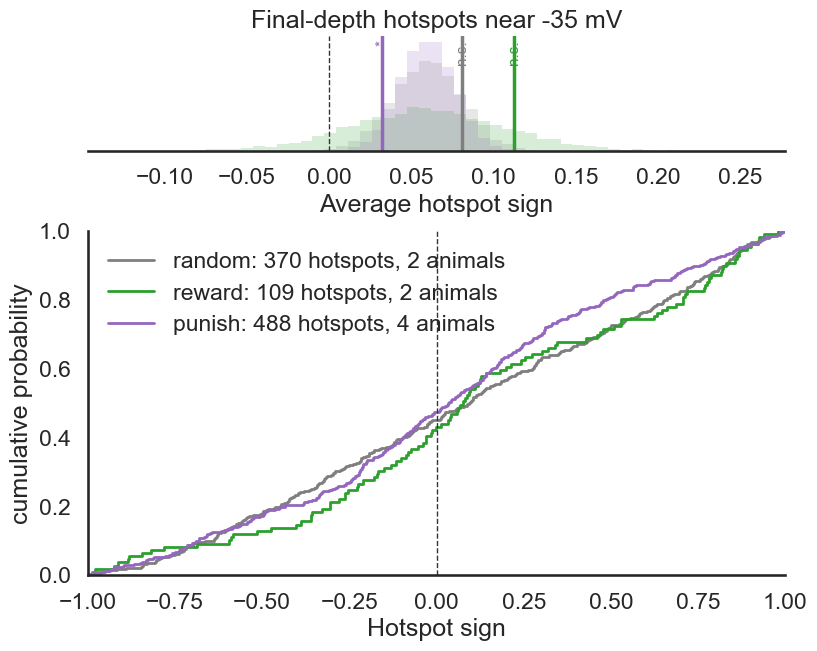

In [18]:
distribution_groups = []
for group in GROUP_ORDER:
    group_rows = hotspot_sign_df[hotspot_sign_df["group"] == group]
    values = group_rows["hotspot_sign"].dropna().to_numpy(dtype=float)
    if len(values) == 0:
        continue
    distribution_groups.append((group, group_rows, values))

if not distribution_groups:
    raise ValueError("No finite hotspot signs are available to plot.")

boot_data, boot_indices = ndap.generate_boot_data(
    [values for _, _, values in distribution_groups],
    random_state=2026,
)
fig, distribution_placeholder = plt.subplots(figsize=(9, 7))
distribution_axes = None
for (group, group_rows, values), boot_idx in zip(
    distribution_groups, boot_indices
):
    label = (
        f"{group}: {len(values)} hotspots, "
        f"{group_rows['animal'].nunique()} animals"
    )
    fig, distribution_axes = ndap.plot_distribution(
        values,
        label=label,
        color=GROUP_COLORS[group],
        ax=distribution_placeholder,
        boot_data=boot_data,
        boot_idx=boot_idx,
        xlabel="Hotspot sign",
        top_xlabel="Average hotspot sign",
        show_legend=True,
        title=f"Final-depth hotspots near {TARGET_VHOLD_MV:g} mV",
    )

ax_mean, ax_cdf = distribution_axes
for ax in (ax_mean, ax_cdf):
    ax.axvline(0, color="0.2", linestyle="--", linewidth=1)
ax_cdf.set_xlim(-1, 1)
plt.show()

## 5. Fixed sign versus sign switching

The hotspot sign index is denoted by $x\in[-1,1]$:

- $x<0$: **excitatory-dominant** hotspot
- $x>0$: **inhibitory-dominant** hotspot
- $|x|$: strength of dominance, independent of direction

This section separates two explanations for the reward-to-punishment distribution shift:

- **H1 — fixed sign / magnitude change:** a hotspot retains its excitatory- or inhibitory-dominant identity, while condition can change $|x|$. For these unpaired data, the testable population-level implication is that the fraction on each side of zero is shared across conditions, while the conditional magnitude distributions may differ.
- **H2 — sign switching / composition change:** condition changes the probability that a hotspot lies on each side of zero, and may also change $|x|$. A condition-specific sign fraction is consistent with sign switching or a change in population composition.

Analysis below test whether cross-zero population mass is needed to explain the observed marginal distributions. Animal-balanced summaries and whole-animal resampling are used whenever possible so animals, not individual hotspots, are the biological replicates.


### 5.1 Separate sign fraction from within-sign magnitude

#### What this analysis measures

This analysis separates **which side of zero a hotspot occupies** from **how strongly it occupies that side**. This prevents a change in the mean sign index from being interpreted as sign switching when it could instead reflect a magnitude change among already excitatory- or inhibitory-dominant hotspots.

#### Analysis steps

1. Keep finite hotspot sign values and classify each hotspot as excitatory-dominant ($x<-δ$), inhibitory-dominant ($x>δ$), or neutral ($|x|\leq\delta$).
2. Exclude neutral values from the two-sign comparison and calculate the inhibitory- and excitatory-dominant fractions for every animal.
3. Report both the pooled hotspot fraction and the preferred **animal-balanced fraction**, in which every contributing animal has equal total weight.
4. Within each condition and sign class, summarize $|x|$ using sample size, animal count, mean, median, and interquartile range.
5. Plot the within-sign magnitude distributions for random, reward, and punish conditions.

#### Expected result under each hypothesis

- **If H1 is true:** the animal-balanced excitatory/inhibitory fractions should be similar across conditions, but one or both conditional $|x|$ distributions may shift.
- **If H2 is true:** the fraction of sign should differ across conditions. Conditional magnitudes may also differ, so a joint change supports a mixture of switching/composition and amplitude effects.

This subsection is descriptive; uncertainty and model-based comparisons are added below.


,n_hotspots,n_animals,pooled_inhibitory_fraction,animal_balanced_inhibitory_fraction,between_animal_sd,animal_balanced_excitatory_fraction
group,,,,,,
random,370,2,0.548649,0.388852,0.326622,0.611148
reward,108,2,0.574074,0.700000,0.267129,0.300000
punish,487,4,0.525667,0.545128,0.131782,0.454872


,group,dominance,n_hotspots,n_animals,median_magnitude,mean_magnitude,q25,q75
0,punish,excitatory-dominant,231,4,0.330698,0.397292,0.154530,0.653813
1,punish,inhibitory-dominant,256,4,0.347124,0.419660,0.174208,0.682677
2,random,excitatory-dominant,167,2,0.415154,0.430642,0.216480,0.629803
3,random,inhibitory-dominant,203,2,0.499947,0.501525,0.240659,0.761081
4,reward,excitatory-dominant,46,2,0.291820,0.378969,0.134511,0.587497
5,reward,inhibitory-dominant,62,2,0.492083,0.479366,0.132120,0.778717


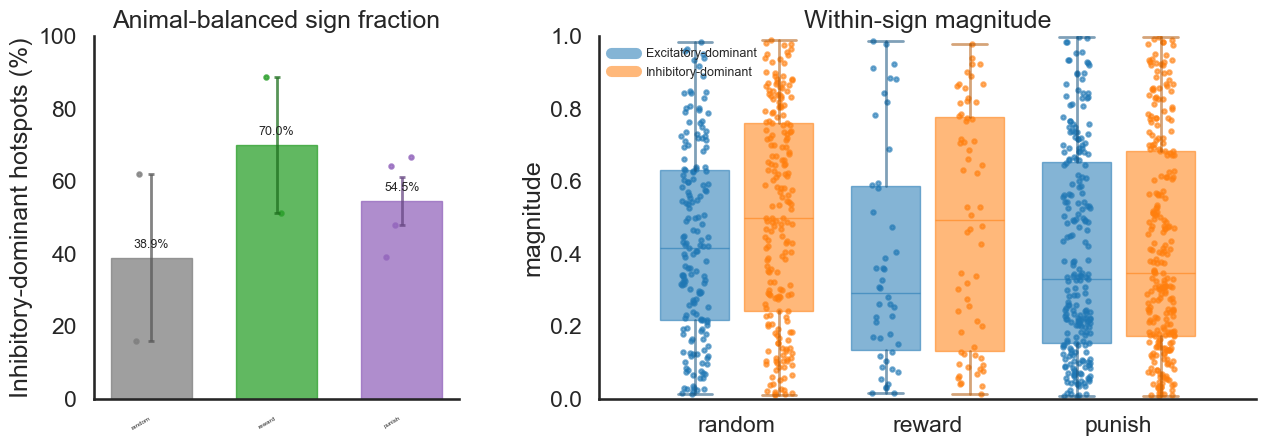

In [19]:
from itertools import combinations, permutations
from math import comb

from scipy.optimize import linprog, minimize
from scipy.sparse import lil_matrix
from scipy.special import betaln, expit, gammaln
from scipy.stats import wasserstein_distance


# Values in [-SIGN_EPSILON, +SIGN_EPSILON] are treated as neutral. Keep this
# at zero for the primary analysis; changing it to 0.005 performs the proposed
# sensitivity analysis without changing any code below.
SIGN_EPSILON = 0.005


def prepare_sign_analysis_data(hotspot_df, epsilon=SIGN_EPSILON):
    """Return finite hotspot signs with explicit biological sign labels."""
    required = {"group", "animal", "hotspot_sign"}
    missing = required.difference(hotspot_df.columns)
    if missing:
        raise ValueError(f"hotspot_df is missing columns: {sorted(missing)}")

    data = hotspot_df.loc[
        hotspot_df["group"].isin(GROUP_ORDER),
        ["group", "animal", "cell", "hotspot_sign"],
    ].copy()
    data["hotspot_sign"] = pd.to_numeric(data["hotspot_sign"], errors="coerce")
    data = data[np.isfinite(data["hotspot_sign"])].copy()
    data["dominance"] = np.select(
        [
            data["hotspot_sign"] < -epsilon,
            data["hotspot_sign"] > epsilon,
        ],
        ["excitatory-dominant", "inhibitory-dominant"],
        default="neutral",
    )
    data["magnitude"] = data["hotspot_sign"].abs()
    return data


sign_analysis_df = prepare_sign_analysis_data(hotspot_sign_df)
decisive_sign_df = sign_analysis_df[
    sign_analysis_df["dominance"] != "neutral"
].copy()
if decisive_sign_df.empty:
    raise ValueError("No non-neutral hotspot signs are available for Section 5.")

# Report both pooled fractions and animal-balanced fractions. The latter gives
# every animal equal total weight and is the preferred biological summary.
animal_sign_fraction_df = (
    decisive_sign_df.assign(
        is_inhibitory=lambda frame: (
            frame["dominance"] == "inhibitory-dominant"
        ).astype(float)
    )
    .groupby(["group", "animal"], observed=True)
    .agg(
        n_hotspots=("hotspot_sign", "size"),
        inhibitory_fraction=("is_inhibitory", "mean"),
    )
    .reset_index()
)
animal_sign_fraction_df["excitatory_fraction"] = (
    1.0 - animal_sign_fraction_df["inhibitory_fraction"]
)

pooled_sign_summary = (
    decisive_sign_df.assign(
        is_inhibitory=lambda frame: (
            frame["dominance"] == "inhibitory-dominant"
        ).astype(float)
    )
    .groupby("group", observed=True)
    .agg(
        n_hotspots=("hotspot_sign", "size"),
        n_animals=("animal", "nunique"),
        pooled_inhibitory_fraction=("is_inhibitory", "mean"),
    )
)
balanced_sign_summary = (
    animal_sign_fraction_df.groupby("group", observed=True)
    .agg(
        animal_balanced_inhibitory_fraction=("inhibitory_fraction", "mean"),
        between_animal_sd=("inhibitory_fraction", "std"),
    )
)
sign_fraction_summary_df = pooled_sign_summary.join(balanced_sign_summary)
sign_fraction_summary_df["animal_balanced_excitatory_fraction"] = (
    1.0 - sign_fraction_summary_df["animal_balanced_inhibitory_fraction"]
)
sign_fraction_summary_df = sign_fraction_summary_df.reindex(GROUP_ORDER)

magnitude_summary_df = (
    decisive_sign_df.groupby(["group", "dominance"], observed=True)
    .agg(
        n_hotspots=("magnitude", "size"),
        n_animals=("animal", "nunique"),
        median_magnitude=("magnitude", "median"),
        mean_magnitude=("magnitude", "mean"),
        q25=("magnitude", lambda values: values.quantile(0.25)),
        q75=("magnitude", lambda values: values.quantile(0.75)),
    )
    .reset_index()
)

display(sign_fraction_summary_df)
display(magnitude_summary_df)

underrepresented_groups = sign_fraction_summary_df.index[
    sign_fraction_summary_df["n_animals"] < 2
].tolist()
if underrepresented_groups:
    print(
        "Caution: fewer than two animals contributed valid hotspots for "
        f"{underrepresented_groups}. Their Section 5 results are descriptive "
        "and cannot estimate between-animal uncertainty."
    )

fig, (ax_fraction, ax_magnitude) = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
    gridspec_kw={"width_ratios": [1, 1.8]},
)

# Panel 1: animal-balanced inhibitory-dominant fraction.
group_positions = np.arange(len(GROUP_ORDER), dtype=float)
inhibitory_percent = (
    100
    * sign_fraction_summary_df.loc[
        GROUP_ORDER, "animal_balanced_inhibitory_fraction"
    ].to_numpy(dtype=float)
)
bar_width = 0.65
fraction_distributions = [
    (
        100
        * animal_sign_fraction_df.loc[
            animal_sign_fraction_df["group"] == group,
            "inhibitory_fraction",
        ].to_numpy(dtype=float)
    )
    for group in GROUP_ORDER
]
ndap.plotScatterBar(
    fraction_distributions,
    labels=GROUP_ORDER,
    style="bar",
    ax=ax_fraction,
    width=bar_width,
    colors=[
        to_rgba(GROUP_COLORS[group], alpha=0.75) for group in GROUP_ORDER
    ],
)
bars = ax_fraction.patches
for bar, value in zip(bars, inhibitory_percent):
    ax_fraction.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax_fraction.set_xticks(group_positions, GROUP_ORDER)
ax_fraction.set_ylabel("Inhibitory-dominant hotspots (%)")
ax_fraction.set_ylim(0, 100)
ax_fraction.set_title("Animal-balanced sign fraction")
for spine in ("top", "right"):
    ax_fraction.spines[spine].set_visible(False)

# Panel 2: within-sign magnitude. Fixed offsets and widths keep every
# excitatory/inhibitory box the same size.
dominance_order = ["excitatory-dominant", "inhibitory-dominant"]
dominance_colors = {
    "excitatory-dominant": "tab:blue",
    "inhibitory-dominant": "tab:orange",
}
box_offsets = [-0.22, 0.22]
box_width = 0.36
positions, distributions, colors = [], [], []
for group_index, group in enumerate(GROUP_ORDER):
    for sign_index, dominance in enumerate(dominance_order):
        values = decisive_sign_df.loc[
            (decisive_sign_df["group"] == group)
            & (decisive_sign_df["dominance"] == dominance),
            "magnitude",
        ].to_numpy()
        if len(values):
            positions.append(group_index + box_offsets[sign_index])
            distributions.append(values)
            colors.append(to_rgba(dominance_colors[dominance], alpha=0.55))

ndap.plotScatterBar(
    distributions,
    style="box",
    ax=ax_magnitude,
    colors=colors,
    positions=positions,
    width=box_width,
    scatter_alpha=0.6,
)
ax_magnitude.plot(
    [], [], color="tab:blue", linewidth=8, alpha=0.55,
    label="Excitatory-dominant",
)
ax_magnitude.plot(
    [], [], color="tab:orange", linewidth=8, alpha=0.55,
    label="Inhibitory-dominant",
)
ax_magnitude.set_xticks(group_positions, GROUP_ORDER)
ax_magnitude.set_ylabel("magnitude")
ax_magnitude.set_ylim(0, 1)
ax_magnitude.set_title("Within-sign magnitude")
ax_magnitude.legend(frameon=False, fontsize=9)
for spine in ("top", "right"):
    ax_magnitude.spines[spine].set_visible(False)

fig.tight_layout(w_pad=2.5)
plt.show()


### 5.2 Minimum and maximum sign-switch mass

#### What this analysis measures

Reward and punish hotspots are unpaired, so an exact switch fraction is not identifiable. However, their animal-balanced inhibitory-dominant probabilities constrain the fraction that would have different signs under any possible coupling of the two marginal distributions. These are the Fréchet bounds on sign disagreement.

Let $p_R=P_{reward}(x>0)$ and $p_P=P_{punish}(x>0)$. Then

$$
S_{switch,min}=|p_P-p_R|
$$

and

$$
S_{switch,max}=1-|p_R+p_P-1|.
$$

The lower bound is the probability mass that **must** cross zero to reconcile the two sign proportions. The upper bound is the largest sign disagreement compatible with those marginals; it is not an estimate of the actual switch rate.

#### Analysis steps

1. Calculate the inhibitory-dominant fraction within each animal.
2. Average those fractions across animals to obtain $p_R$ and $p_P$ with equal animal weight.
3. Calculate $S_{switch,min}$ and $S_{switch,max}$ from the equations above.
4. If reward and punish each contain at least two contributing animals, resample whole animals within condition 10,000 times and report cluster-bootstrap intervals for both bounds. Otherwise, report only the descriptive bounds.

#### Expected result under each hypothesis

- **If H1 is true:** $p_R$ and $p_P$ should be similar, so $S_{switch,min}$ should be near zero within animal-level uncertainty.
- **If H2 is true:** a clearly positive $S_{switch,min}$ indicates that some cross-zero population mass is required. A large lower bound is stronger distribution-level evidence for switching/composition change.

These bounds do not reveal which hotspots switched or the direction of individual transitions.


In [20]:
def switch_fraction_bounds(p_positive_a, p_positive_b):
    """Fréchet bounds on sign disagreement from two positive marginals."""
    p_positive_a = float(p_positive_a)
    p_positive_b = float(p_positive_b)
    lower = abs(p_positive_b - p_positive_a)
    upper = 1.0 - abs(p_positive_a + p_positive_b - 1.0)
    return lower, upper


def bootstrap_switch_bounds(animal_fraction_df, n_bootstrap=10_000, seed=2026):
    """Cluster-bootstrap bounds by resampling animals within each condition."""
    fractions = {
        group: animal_fraction_df.loc[
            animal_fraction_df["group"] == group, "inhibitory_fraction"
        ].to_numpy(dtype=float)
        for group in ("reward", "punish")
    }
    if any(len(values) == 0 for values in fractions.values()):
        raise ValueError("Reward and punish must each contain at least one animal.")

    rng = np.random.default_rng(seed)
    samples = np.empty((n_bootstrap, 2), dtype=float)
    for index in range(n_bootstrap):
        p_reward = rng.choice(
            fractions["reward"], len(fractions["reward"]), replace=True
        ).mean()
        p_punish = rng.choice(
            fractions["punish"], len(fractions["punish"]), replace=True
        ).mean()
        samples[index] = switch_fraction_bounds(p_reward, p_punish)
    return samples


p_inhibitory = (
    animal_sign_fraction_df.groupby("group", observed=True)[
        "inhibitory_fraction"
    ].mean()
)
switch_min, switch_max = switch_fraction_bounds(
    p_inhibitory["reward"], p_inhibitory["punish"]
)
comparison_animal_counts = animal_sign_fraction_df.groupby(
    "group", observed=True
)["animal"].nunique()
bootstrap_is_estimable = all(
    comparison_animal_counts.get(group, 0) >= 2
    for group in ("reward", "punish")
)
if bootstrap_is_estimable:
    switch_bound_samples = bootstrap_switch_bounds(animal_sign_fraction_df)
    lower_ci = np.percentile(switch_bound_samples, 2.5, axis=0)
    upper_ci = np.percentile(switch_bound_samples, 97.5, axis=0)
else:
    switch_bound_samples = np.empty((0, 2))
    lower_ci = np.repeat(np.nan, 2)
    upper_ci = np.repeat(np.nan, 2)
switch_bounds_df = pd.DataFrame(
    {
        "estimate": [switch_min, switch_max],
        "cluster-bootstrap 2.5%": lower_ci,
        "cluster-bootstrap 97.5%": upper_ci,
    },
    index=["minimum sign-switch mass", "maximum sign-switch mass"],
)

display(
    pd.Series(
        {
            "reward P(inhibitory-dominant)": p_inhibitory["reward"],
            "punish P(inhibitory-dominant)": p_inhibitory["punish"],
        },
        name="animal-balanced estimate",
    ).to_frame()
)
display(switch_bounds_df)
if not bootstrap_is_estimable:
    print(
        "Cluster-bootstrap intervals are not reported because reward and "
        "punish must each have at least two contributing animals."
    )
print(
    "These are coupling bounds implied by unpaired marginal distributions; "
    "they do not identify which individual hotspots switched sign."
)


,animal-balanced estimate
reward P(inhibitory-dominant),0.700000
punish P(inhibitory-dominant),0.545128


,estimate,cluster-bootstrap 2.5%,cluster-bootstrap 97.5%
minimum sign-switch mass,0.154872,0.012402,0.412361
maximum sign-switch mass,0.754872,0.497383,0.987639


These are coupling bounds implied by unpaired marginal distributions; they do not identify which individual hotspots switched sign.


### 5.3 Decompose the reward-to-punishment mean change

#### What this analysis measures

The overall mean sign index = total inhibitory contribution - total excitatory contribution. For each condition it can be written as

$$
E[x]=p_I m_I-(1-p_I)m_E,
$$

where $p_I=P(x>0)$ (sign fraction), $m_I=E(|x|\mid x>0)$ (inhibitory magnitude), and $m_E=E(|x|\mid x<0)$ (excitatory magnitude). The analysis decomposes the reward-to-punishment change in $E[x]$ into contributions from these three factors.

#### Analysis steps

1. Give every represented animal equal total weight within its condition.
2. Estimate $p_I$, $m_E$, $m_I$, and the reconstructed mean sign for random, reward, and punish.
3. For the reward-to-punishment contrast, replace the three reward factors with their punish values in all $3!=6$ possible orders. For each order, ask: When I changed this particular knob, how much did the mean move?
4. To get Shapley contribution, average each factor's marginal contribution across the six orders
5. Verify numerically that the three contributions sum to the observed punish-minus-reward mean change, then plot the signed contributions.

#### Expected result under each hypothesis

- **If H1 is true:** the sign-fraction contribution should be near zero, while changes in excitatory- and/or inhibitory-dominant magnitude should explain most of the mean shift.
- **If H2 is true:** the sign-fraction contribution should account for a substantial part of the mean shift. Nonzero magnitude contributions would indicate that switching/composition and amplitude changes occur together.

The decomposition attributes the observed mean difference; by itself it is not a significance test or proof of individual switching.


,p_inhibitory,excitatory_magnitude,inhibitory_magnitude,mean_sign
group,,,,
random,0.388852,0.469150,0.461642,-0.107210
reward,0.700000,0.389500,0.575207,0.285794
punish,0.545128,0.377018,0.402838,0.048104


,contribution,signed contribution (%)
sign fraction,-0.135092,-56.835115
excitatory-dominant magnitude,0.004711,1.982106
inhibitory-dominant magnitude,-0.107310,-45.146991
total reward → punish change,-0.237691,-100.000000


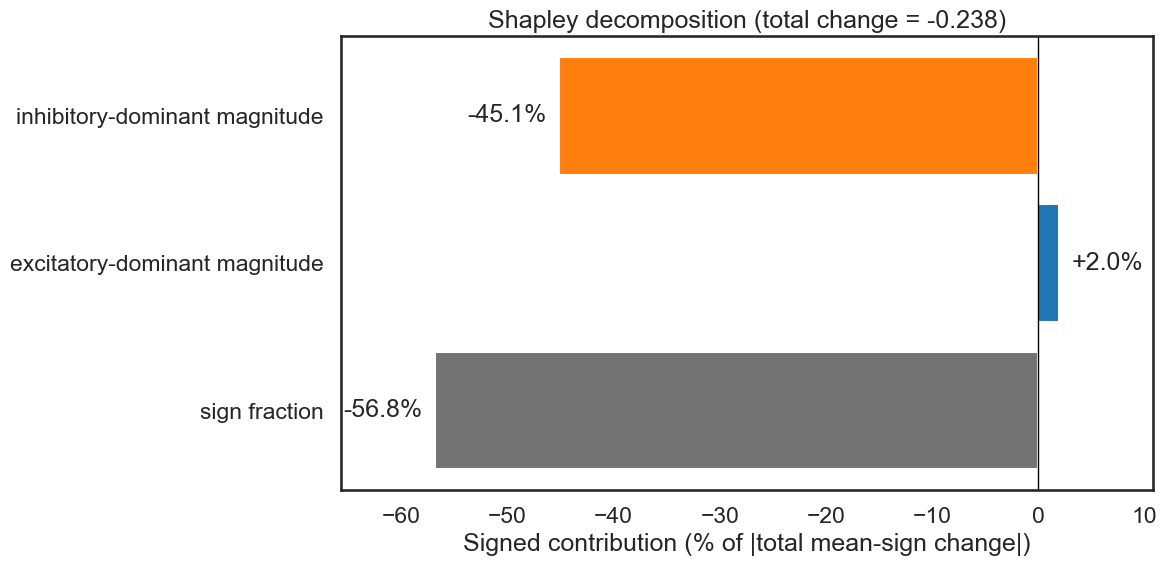

In [28]:
def equal_animal_weights(frame):
    """Weights that give every represented animal equal total mass."""
    if frame.empty:
        return np.array([], dtype=float)
    counts = frame.groupby("animal", observed=True)["animal"].transform("size")
    weights = 1.0 / counts.to_numpy(dtype=float)
    return weights / weights.sum()


def condition_mean_components(frame, group):
    """Return factors in E[x] = p*m_positive - (1-p)*m_negative."""
    rows = frame[frame["group"] == group]
    weights = equal_animal_weights(rows)
    is_positive = (
        rows["dominance"].to_numpy() == "inhibitory-dominant"
    )
    if not is_positive.any() or is_positive.all():
        raise ValueError(f"{group} needs observations on both sides of zero.")

    p_positive = np.sum(weights[is_positive])
    negative_magnitude = np.average(
        rows.loc[~is_positive, "magnitude"], weights=weights[~is_positive]
    )
    positive_magnitude = np.average(
        rows.loc[is_positive, "magnitude"], weights=weights[is_positive]
    )
    mean_sign = (
        p_positive * positive_magnitude
        - (1.0 - p_positive) * negative_magnitude
    )
    return {
        "p_inhibitory": p_positive,
        "excitatory_magnitude": negative_magnitude,
        "inhibitory_magnitude": positive_magnitude,
        "mean_sign": mean_sign,
    }


def mean_from_factors(factors):
    p_positive = factors["p_inhibitory"]
    return (
        p_positive * factors["inhibitory_magnitude"]
        - (1.0 - p_positive) * factors["excitatory_magnitude"]
    )


def shapley_mean_decomposition(baseline, comparison):
    """Exact symmetric three-factor decomposition over all 3! orderings."""
    factor_names = [
        "p_inhibitory",
        "excitatory_magnitude",
        "inhibitory_magnitude",
    ]
    contributions = dict.fromkeys(factor_names, 0.0)
    orderings = list(permutations(factor_names))

    for ordering in orderings:
        state = {name: baseline[name] for name in factor_names}
        previous_value = mean_from_factors(state)
        for name in ordering:
            state[name] = comparison[name]
            next_value = mean_from_factors(state)
            contributions[name] += next_value - previous_value
            previous_value = next_value

    return {
        name: value / len(orderings) for name, value in contributions.items()
    }


condition_components_df = pd.DataFrame.from_dict(
    {
        group: condition_mean_components(decisive_sign_df, group)
        for group in GROUP_ORDER
    },
    orient="index",
).rename_axis("group")

reward_components = condition_components_df.loc["reward"].to_dict()
punish_components = condition_components_df.loc["punish"].to_dict()
decomposition = shapley_mean_decomposition(
    reward_components, punish_components
)
mean_change = (
    punish_components["mean_sign"] - reward_components["mean_sign"]
)
mean_decomposition_df = pd.DataFrame(
    {
        "contribution": [
            decomposition["p_inhibitory"],
            decomposition["excitatory_magnitude"],
            decomposition["inhibitory_magnitude"],
        ]
    },
    index=[
        "sign fraction",
        "excitatory-dominant magnitude",
        "inhibitory-dominant magnitude",
    ],
)
mean_decomposition_df.loc["total reward → punish change"] = mean_change

if not np.isclose(
    mean_decomposition_df.iloc[:3, 0].sum(), mean_change, atol=1e-12
):
    raise RuntimeError("Shapley contributions do not reconstruct the mean change.")

if np.isclose(mean_change, 0.0, atol=1e-12):
    raise ValueError(
        "Signed contribution percentages are undefined when the total "
        "mean-sign change is zero."
    )
mean_decomposition_df["signed contribution (%)"] = (
    100 * mean_decomposition_df["contribution"] / abs(mean_change)
)

display(condition_components_df)
display(mean_decomposition_df)

fig, ax = plt.subplots(figsize=(12, 6))
component_rows = mean_decomposition_df.iloc[:3]
bars = ax.barh(
    component_rows.index,
    component_rows["signed contribution (%)"],
    color=["0.45", "tab:blue", "tab:orange"],
)
label_padding = 0.02 * component_rows["signed contribution (%)"].abs().max()
for bar, value in zip(bars, component_rows["signed contribution (%)"]):
    ax.text(
        value + (label_padding if value >= 0 else -label_padding),
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.1f}%",
        ha="left" if value >= 0 else "right",
        va="center",
    )
ax.axvline(0, color="black", linewidth=1)
ax.margins(x=0.15)
ax.set_xlabel("Signed contribution (% of |total mean-sign change|)")
ax.set_title(f"Shapley decomposition (total change = {mean_change:+.3f})")
fig.tight_layout()
plt.show()


### 5.4 Sign-constrained optimal transport

#### What this analysis measures

Optimal transport asks how reward probability mass must be reassigned to reproduce the punish distribution. It provides a distribution-level comparison between a strict sign-fixed explanation, where transport across zero is forbidden, and a sign-switching explanation, where cross-zero transport is allowed.

For source bin $x_i$ and target bin $x_j$, the implemented cost is

$$
C(x_i,x_j)=|x_i-x_j|^2+\lambda\,I[\operatorname{sign}(x_i)\neq\operatorname{sign}(x_j)].
$$

#### Analysis steps

1. Convert the animal-balanced reward and punish distributions into 80 common bins spanning $[-1,1]$ (bin width $0.025$).
2. Solve balanced transport with cross-zero entries fixed to zero. This strict sign-fixed problem is feasible only when reward and punish have exactly the same total mass on each side of zero.
3. Solve unconstrained transport with $\lambda=0$ and report its squared movement cost and cross-zero mass.
4. Repeat over increasing $\lambda$ values. For each solution, separate the squared movement cost, cross-zero mass, and total penalized objective.
5. Plot how movement cost and cross-zero mass change as switching becomes increasingly expensive.

#### Expected result under each hypothesis

- **If H1 is true:** strict sign-fixed transport should be feasible, and allowing cross-zero movement should provide little improvement. The optimal cross-zero mass should fall to zero with a modest penalty, while remaining differences are explained by movement within each sign.
- **If H2 is true:** strict sign-fixed transport is infeasible when sign proportions differ, or unconstrained transport obtains a much better explanation by moving appreciable mass across zero. Cross-zero mass that persists even for large $\lambda$ reflects mass forced by the marginal sign imbalance; its minimum is linked to Section 5.2's lower bound.

This is a transport between unpaired distributions. Cross-zero transported mass is evidence that a switching/composition model is useful, not identification of specific switching hotspots.


In [29]:
def animal_balanced_histogram(frame, group, bin_edges):
    """Discretize one condition while preserving equal animal weight."""
    rows = frame[frame["group"] == group]
    if rows.empty:
        raise ValueError(f"No observations for {group}.")
    mass, _ = np.histogram(
        rows["hotspot_sign"],
        bins=bin_edges,
        weights=equal_animal_weights(rows),
    )
    mass = mass.astype(float)
    mass /= mass.sum()
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    keep = mass > 0
    return centers[keep], mass[keep]


def solve_sign_penalized_transport(
    source_x,
    source_mass,
    target_x,
    target_mass,
    crossing_penalty=0.0,
    forbid_crossing=False,
):
    """Solve balanced discrete OT with squared movement and sign penalty."""
    source_x = np.asarray(source_x, dtype=float)
    target_x = np.asarray(target_x, dtype=float)
    source_mass = np.asarray(source_mass, dtype=float)
    target_mass = np.asarray(target_mass, dtype=float)
    source_mass = source_mass / source_mass.sum()
    target_mass = target_mass / target_mass.sum()

    n_source, n_target = len(source_x), len(target_x)
    movement_cost = (source_x[:, None] - target_x[None, :]) ** 2
    crossing = np.signbit(source_x[:, None]) != np.signbit(target_x[None, :])
    objective = movement_cost + crossing_penalty * crossing

    # The final target constraint is redundant because both marginals sum to 1.
    constraints = lil_matrix(
        (n_source + n_target - 1, n_source * n_target), dtype=float
    )
    for source_index in range(n_source):
        start = source_index * n_target
        constraints[source_index, start : start + n_target] = 1.0
    for target_index in range(n_target - 1):
        constraints[
            n_source + target_index, target_index::n_target
        ] = 1.0
    constraint_values = np.concatenate([source_mass, target_mass[:-1]])

    if forbid_crossing:
        bounds = [
            (0.0, 0.0) if is_crossing else (0.0, None)
            for is_crossing in crossing.ravel()
        ]
    else:
        bounds = (0.0, None)

    result = linprog(
        objective.ravel(),
        A_eq=constraints.tocsr(),
        b_eq=constraint_values,
        bounds=bounds,
        method="highs",
    )
    if not result.success:
        return {
            "success": False,
            "message": result.message,
            "movement_cost": np.inf,
            "cross_zero_mass": np.nan,
            "penalized_cost": np.inf,
        }

    plan = result.x.reshape(n_source, n_target)
    cross_zero_mass = float(plan[crossing].sum())
    squared_movement = float(np.sum(plan * movement_cost))
    return {
        "success": True,
        "message": result.message,
        "movement_cost": squared_movement,
        "cross_zero_mass": cross_zero_mass,
        "penalized_cost": squared_movement + crossing_penalty * cross_zero_mass,
    }


# Binning keeps the transport program small and makes all lambda values use the
# same empirical support. Eighty bins preserve 0.025 sign-index resolution.
TRANSPORT_BIN_EDGES = np.linspace(-1.0, 1.0, 81)
reward_x, reward_mass = animal_balanced_histogram(
    decisive_sign_df, "reward", TRANSPORT_BIN_EDGES
)
punish_x, punish_mass = animal_balanced_histogram(
    decisive_sign_df, "punish", TRANSPORT_BIN_EDGES
)

strict_transport = solve_sign_penalized_transport(
    reward_x,
    reward_mass,
    punish_x,
    punish_mass,
    forbid_crossing=True,
)
transport_lambdas = np.array([0.0, 1e-3, 1e-2, 3e-2, 0.1, 0.3, 1.0, 3.0, 10.0])
transport_records = []
for penalty in transport_lambdas:
    solution = solve_sign_penalized_transport(
        reward_x,
        reward_mass,
        punish_x,
        punish_mass,
        crossing_penalty=penalty,
    )
    transport_records.append(
        {
            "lambda": penalty,
            "squared movement cost": solution["movement_cost"],
            "cross-zero mass": solution["cross_zero_mass"],
            "penalized objective": solution["penalized_cost"],
        }
    )
transport_df = pd.DataFrame(transport_records)

strict_summary_df = pd.DataFrame(
    [
        {
            "model": "strict sign-fixed (crossing forbidden)",
            "feasible": strict_transport["success"],
            "squared movement cost": strict_transport["movement_cost"],
            "cross-zero mass": strict_transport["cross_zero_mass"],
            "message": strict_transport["message"],
        },
        {
            "model": "unconstrained sign-switch (lambda=0)",
            "feasible": True,
            "squared movement cost": transport_df.iloc[0][
                "squared movement cost"
            ],
            "cross-zero mass": transport_df.iloc[0]["cross-zero mass"],
            "message": "optimal balanced transport",
        },
    ]
)
display(strict_summary_df)
display(transport_df)

if not strict_transport["success"]:
    print(
        "Strict sign-fixed balanced transport is infeasible because reward and "
        "punish contain different mass on the two sides of zero. The minimum "
        "cross-zero mass is therefore constrained by Section 5.2's lower bound."
    )


,model,feasible,squared movement cost,cross-zero mass,message
0,strict sign-fixed (crossing forbidden),False,inf,NaN,The problem is infeasible. (HiGHS Status 8: mo...
1,unconstrained sign-switch (lambda=0),True,0.079289,0.154872,optimal balanced transport


,lambda,squared movement cost,cross-zero mass,penalized objective
0,0.000,0.079289,0.154872,0.079289
1,0.001,0.079289,0.154872,0.079443
2,0.010,0.079289,0.154872,0.080837
3,0.030,0.079289,0.154872,0.083935
4,0.100,0.079289,0.154872,0.094776
5,0.300,0.079289,0.154872,0.125750
6,1.000,0.079289,0.154872,0.234160
7,3.000,0.079289,0.154872,0.543904
8,10.000,0.079289,0.154872,1.628008


Strict sign-fixed balanced transport is infeasible because reward and punish contain different mass on the two sides of zero. The minimum cross-zero mass is therefore constrained by Section 5.2's lower bound.


### 5.5 Population model fitting and validation

#### What this analysis measures

This subsection makes the H1-versus-H2 comparison explicit at the animal level. Because hotspots are unpaired across conditions, the identifiable comparison is between a model with one shared population sign probability and a model with condition-specific sign probabilities—not a model that estimates individual $-\rightarrow+$ or $+\rightarrow-$ transition rates.

- **H1 model:** random, reward, and punish share one $p_I=P(x>0)$.
- **H2 model:** random, reward, and punish have separate $p_I$ values.

Both models use the same condition- and sign-specific magnitude distributions, so their predictive-performance difference isolates the sign-composition component.

#### Analysis steps

1. For each animal, count the number of inhibitory-dominant hotspots $k_a$ among $n_a$ decisive hotspots.
2. Fit H1 and H2 with a beta-binomial likelihood. This treats the animal as the replicate and uses a shared concentration parameter to allow more between-animal variation than a simple binomial model.
3. Obtain regularized maximum-a-posteriori estimates using weak priors on the sign logits and concentration. Approximate parameter uncertainty with the inverse-Hessian (Laplace) covariance.
4. Fit animal-balanced logit-normal magnitude distributions separately for each condition and observed sign.
5. Generate 2,000 approximate posterior-predictive experiments with the observed number of hotspots per animal. Compare observed and predictive intervals for $P(x>0)$, $E[x]$, $E(|x|\mid x<0)$, and $E(|x|\mid x>0)$.
6. Plot the predictive distribution of the punish-minus-reward inhibitory fraction under both models and mark the observed value.
7. When every condition has at least two contributing animals, perform leave-one-animal-out refitting and compare sign expected log predictive density (ELPD). If holding out an animal would remove its condition from training, report the comparison as not estimable.

#### Expected result under each hypothesis

- **If H1 is true:** the shared-sign model should reproduce each condition's sign fraction and the reward-to-punishment difference. H2 should provide little or no out-of-animal predictive gain, so $\Delta\mathrm{ELPD}=\mathrm{ELPD}_{H2}-\mathrm{ELPD}_{H1}$ should be near zero or negative.
- **If H2 is true:** the observed condition-specific sign fractions—especially the punish-minus-reward difference—should fall poorly within H1 predictions but be reproduced by H2. With enough animals, H2 should have positive leave-one-animal-out $\Delta\mathrm{ELPD}$.
- **If both sign and magnitude change:** H2 improves sign prediction, while the conditional magnitude summaries also differ across conditions.

Posterior-predictive fit alone asks whether a model can generate data like those observed; leave-one-animal-out ELPD asks whether the added condition-specific sign parameters improve prediction. Neither identifies directional switching rates without paired hotspots or additional mechanistic constraints.


In [24]:
# This is the identifiable population-level H1-vs-H2 comparison for unpaired
# hotspots. H1 has one shared sign probability; H2 has one per condition. A
# beta-binomial likelihood makes the animal, rather than the hotspot, the unit
# of replication and allows extra between-animal variation.

SIGN_LOGIT_PRIOR_SD = 2.0
LOG_CONCENTRATION_PRIOR_MEAN = np.log(10.0)
LOG_CONCENTRATION_PRIOR_SD = 2.0
N_POSTERIOR_PREDICTIVE = 2_000


def beta_binomial_logpmf(k, n, alpha, beta):
    """Log PMF of a beta-binomial count."""
    return (
        gammaln(n + 1)
        - gammaln(k + 1)
        - gammaln(n - k + 1)
        + betaln(k + alpha, n - k + beta)
        - betaln(alpha, beta)
    )


def make_animal_sign_counts(frame):
    counts = (
        frame.assign(
            is_positive=(
                frame["dominance"] == "inhibitory-dominant"
            ).astype(int)
        )
        .groupby(["group", "animal"], observed=True)
        .agg(
            n=("is_positive", "size"),
            k_positive=("is_positive", "sum"),
        )
        .reset_index()
    )
    counts["group"] = pd.Categorical(
        counts["group"], categories=GROUP_ORDER, ordered=True
    )
    return counts.sort_values(["group", "animal"]).reset_index(drop=True)


animal_sign_counts_df = make_animal_sign_counts(decisive_sign_df)


def fit_beta_binomial_sign_model(counts, condition_specific):
    """Regularized MAP fit of a clustered H1 or H2 sign model."""
    n_logits = len(GROUP_ORDER) if condition_specific else 1
    pooled_p = np.clip(counts["k_positive"].sum() / counts["n"].sum(), 0.01, 0.99)
    initial = np.r_[
        np.repeat(np.log(pooled_p / (1.0 - pooled_p)), n_logits),
        LOG_CONCENTRATION_PRIOR_MEAN,
    ]

    group_index = counts["group"].map(
        {group: index for index, group in enumerate(GROUP_ORDER)}
    ).to_numpy(dtype=int)
    k = counts["k_positive"].to_numpy(dtype=float)
    n = counts["n"].to_numpy(dtype=float)

    def negative_log_posterior(parameters):
        logits = parameters[:n_logits]
        log_concentration = parameters[-1]
        probabilities = expit(logits)
        concentration = np.exp(np.clip(log_concentration, -8.0, 12.0))
        p_observation = (
            probabilities[group_index]
            if condition_specific
            else np.repeat(probabilities[0], len(counts))
        )
        alpha = np.clip(p_observation * concentration, 1e-9, None)
        beta = np.clip((1.0 - p_observation) * concentration, 1e-9, None)
        log_likelihood = beta_binomial_logpmf(k, n, alpha, beta).sum()
        log_prior = -0.5 * np.sum((logits / SIGN_LOGIT_PRIOR_SD) ** 2)
        log_prior -= 0.5 * (
            (log_concentration - LOG_CONCENTRATION_PRIOR_MEAN)
            / LOG_CONCENTRATION_PRIOR_SD
        ) ** 2
        return -(log_likelihood + log_prior)

    result = minimize(negative_log_posterior, initial, method="BFGS")
    if not np.isfinite(result.fun):
        raise RuntimeError("The beta-binomial model fit produced a non-finite result.")

    covariance = np.asarray(result.hess_inv, dtype=float)
    covariance = (covariance + covariance.T) / 2.0
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    covariance = eigenvectors @ np.diag(np.clip(eigenvalues, 1e-8, None)) @ eigenvectors.T
    return {
        "condition_specific": condition_specific,
        "result": result,
        "parameters": result.x,
        "covariance": covariance,
    }


def model_sign_probabilities(fit, parameters=None):
    if parameters is None:
        parameters = fit["parameters"]
    logits = parameters[:-1]
    if fit["condition_specific"]:
        values = expit(logits)
    else:
        values = np.repeat(expit(logits[0]), len(GROUP_ORDER))
    return pd.Series(values, index=GROUP_ORDER, name="P(inhibitory-dominant)")


sign_model_h1 = fit_beta_binomial_sign_model(
    animal_sign_counts_df, condition_specific=False
)
sign_model_h2 = fit_beta_binomial_sign_model(
    animal_sign_counts_df, condition_specific=True
)
fitted_sign_probabilities_df = pd.concat(
    {
        "H1: shared sign composition": model_sign_probabilities(sign_model_h1),
        "H2: condition-specific composition": model_sign_probabilities(sign_model_h2),
    },
    axis=1,
)
display(fitted_sign_probabilities_df)


def fit_logit_magnitude_parameters(frame):
    """Fit animal-balanced logit-normal magnitude parameters by group/sign."""
    parameters = {}
    for (group, dominance), rows in frame.groupby(
        ["group", "dominance"], observed=True
    ):
        weights = equal_animal_weights(rows)
        magnitude = np.clip(rows["magnitude"].to_numpy(dtype=float), 1e-5, 1 - 1e-5)
        transformed = np.log(magnitude / (1.0 - magnitude))
        mean = np.average(transformed, weights=weights)
        variance = np.average((transformed - mean) ** 2, weights=weights)
        parameters[(group, dominance)] = (mean, max(np.sqrt(variance), 0.05))
    return parameters


magnitude_parameters = fit_logit_magnitude_parameters(decisive_sign_df)


def posterior_predictive_summaries(
    fit,
    counts,
    magnitude_parameters,
    n_draws=N_POSTERIOR_PREDICTIVE,
    seed=2026,
):
    """Laplace-approximate PPC with the observed number of spots per animal."""
    rng = np.random.default_rng(seed)
    parameter_draws = rng.multivariate_normal(
        fit["parameters"], fit["covariance"], size=n_draws
    )
    metrics = [
        "p_inhibitory",
        "mean_sign",
        "excitatory_magnitude",
        "inhibitory_magnitude",
    ]
    simulations = {
        (group, metric): np.full(n_draws, np.nan)
        for group in GROUP_ORDER
        for metric in metrics
    }

    rows_by_group = {
        group: counts[counts["group"] == group] for group in GROUP_ORDER
    }
    for draw_index, parameters in enumerate(parameter_draws):
        probabilities = model_sign_probabilities(fit, parameters)
        concentration = np.exp(np.clip(parameters[-1], -8.0, 12.0))
        for group in GROUP_ORDER:
            animal_metrics = []
            for row in rows_by_group[group].itertuples(index=False):
                p = float(probabilities[group])
                animal_p = rng.beta(p * concentration, (1.0 - p) * concentration)
                n_positive = rng.binomial(int(row.n), animal_p)
                n_negative = int(row.n) - n_positive

                positive_values = np.array([], dtype=float)
                negative_values = np.array([], dtype=float)
                if n_positive:
                    mu, sigma = magnitude_parameters[
                        (group, "inhibitory-dominant")
                    ]
                    positive_values = expit(rng.normal(mu, sigma, n_positive))
                if n_negative:
                    mu, sigma = magnitude_parameters[
                        (group, "excitatory-dominant")
                    ]
                    negative_values = expit(rng.normal(mu, sigma, n_negative))

                animal_metrics.append(
                    {
                        "p_inhibitory": n_positive / int(row.n),
                        "mean_sign": (
                            positive_values.sum() - negative_values.sum()
                        ) / int(row.n),
                        "excitatory_magnitude": (
                            negative_values.mean() if n_negative else np.nan
                        ),
                        "inhibitory_magnitude": (
                            positive_values.mean() if n_positive else np.nan
                        ),
                    }
                )
            animal_metrics = pd.DataFrame(animal_metrics)
            for metric in metrics:
                simulations[(group, metric)][draw_index] = animal_metrics[
                    metric
                ].mean(skipna=True)
    return simulations


def summarize_posterior_predictive(simulations, observed_components, model_name):
    records = []
    for group in GROUP_ORDER:
        for metric in (
            "p_inhibitory",
            "mean_sign",
            "excitatory_magnitude",
            "inhibitory_magnitude",
        ):
            values = simulations[(group, metric)]
            observed = observed_components.loc[group, metric]
            records.append(
                {
                    "model": model_name,
                    "group": group,
                    "metric": metric,
                    "observed": observed,
                    "predictive median": np.nanmedian(values),
                    "predictive 2.5%": np.nanpercentile(values, 2.5),
                    "predictive 97.5%": np.nanpercentile(values, 97.5),
                }
            )
    return pd.DataFrame(records)


h1_ppc = posterior_predictive_summaries(
    sign_model_h1, animal_sign_counts_df, magnitude_parameters, seed=2026
)
h2_ppc = posterior_predictive_summaries(
    sign_model_h2, animal_sign_counts_df, magnitude_parameters, seed=2027
)
posterior_predictive_df = pd.concat(
    [
        summarize_posterior_predictive(
            h1_ppc, condition_components_df, "H1: shared sign composition"
        ),
        summarize_posterior_predictive(
            h2_ppc, condition_components_df, "H2: condition-specific composition"
        ),
    ],
    ignore_index=True,
)
display(posterior_predictive_df)


def held_out_log_predictive(fit, held_out_row):
    probabilities = model_sign_probabilities(fit)
    p = float(probabilities[str(held_out_row.group)])
    concentration = np.exp(np.clip(fit["parameters"][-1], -8.0, 12.0))
    return float(
        beta_binomial_logpmf(
            held_out_row.k_positive,
            held_out_row.n,
            p * concentration,
            (1.0 - p) * concentration,
        )
    )


# Leave out complete animals, refit, and score the held-out sign count. This is
# only identifiable when every condition retains at least one training animal.
animals_per_group = animal_sign_counts_df.groupby(
    "group", observed=True
)["animal"].nunique().reindex(GROUP_ORDER, fill_value=0)
loao_is_estimable = bool((animals_per_group >= 2).all())
loao_log_scores_df = pd.DataFrame()
loao_summary_df = pd.DataFrame()
h1_elpd = np.nan
h2_elpd = np.nan

if loao_is_estimable:
    loao_records = []
    for held_out_index, held_out in animal_sign_counts_df.iterrows():
        training_counts = animal_sign_counts_df.drop(index=held_out_index)
        for model_name, condition_specific in (
            ("H1: shared sign composition", False),
            ("H2: condition-specific composition", True),
        ):
            fitted = fit_beta_binomial_sign_model(
                training_counts, condition_specific
            )
            loao_records.append(
                {
                    "model": model_name,
                    "held-out group": str(held_out["group"]),
                    "held-out animal": held_out["animal"],
                    "sign log predictive density": held_out_log_predictive(
                        fitted, held_out
                    ),
                }
            )
    loao_log_scores_df = pd.DataFrame(loao_records)
    loao_summary_df = (
        loao_log_scores_df.groupby("model", observed=True)[
            "sign log predictive density"
        ]
        .agg([("sign ELPD", "sum"), ("mean per animal", "mean")])
        .sort_values("sign ELPD", ascending=False)
    )
    h1_elpd = loao_summary_df.loc[
        "H1: shared sign composition", "sign ELPD"
    ]
    h2_elpd = loao_summary_df.loc[
        "H2: condition-specific composition", "sign ELPD"
    ]
    loao_summary_df["delta ELPD vs H1"] = (
        loao_summary_df["sign ELPD"] - h1_elpd
    )
    display(loao_summary_df)
    display(loao_log_scores_df)
else:
    print(
        "Leave-one-animal-out model comparison is not estimable: each "
        "condition needs at least two animals with valid hotspots so the held-"
        "out animal's condition remains represented in training. Contributing "
        f"animal counts: {animals_per_group.to_dict()}"
    )

observed_delta_p = (
    condition_components_df.loc["punish", "p_inhibitory"]
    - condition_components_df.loc["reward", "p_inhibitory"]
)

,H1: shared sign composition,H2: condition-specific composition
random,0.532686,0.394053
reward,0.532686,0.668039
punish,0.532686,0.539381


,model,group,metric,observed,predictive median,predictive 2.5%,predictive 97.5%
0,H1: shared sign composition,random,p_inhibitory,0.388852,0.565061,0.008772,0.920157
1,H1: shared sign composition,random,mean_sign,-0.107210,0.030046,-0.437944,0.326239
2,H1: shared sign composition,random,excitatory_magnitude,0.469150,0.447170,0.371835,0.523175
3,H1: shared sign composition,random,inhibitory_magnitude,0.461642,0.393107,0.308684,0.474877
4,H1: shared sign composition,reward,p_inhibitory,0.700000,0.566667,0.000000,0.927778
5,H1: shared sign composition,reward,mean_sign,0.285794,0.109874,-0.411622,0.455615
6,H1: shared sign composition,reward,excitatory_magnitude,0.389500,0.421178,0.291120,0.571348
7,H1: shared sign composition,reward,inhibitory_magnitude,0.575207,0.520594,0.368151,0.665622
8,H1: shared sign composition,punish,p_inhibitory,0.545128,0.543365,0.040698,0.912527
9,H1: shared sign composition,punish,mean_sign,0.048104,0.049002,-0.335337,0.333065


,sign ELPD,mean per animal,delta ELPD vs H1
model,,,
H1: shared sign composition,-38.361250,-4.795156,0.000000
H2: condition-specific composition,-46.799052,-5.849881,-8.437802


,model,held-out group,held-out animal,sign log predictive density
0,H1: shared sign composition,random,SL452,-5.182578
1,H2: condition-specific composition,random,SL452,-10.748624
2,H1: shared sign composition,random,SL458,-8.114690
3,H2: condition-specific composition,random,SL458,-9.134895
4,H1: shared sign composition,reward,SL456,-3.922677
5,H2: condition-specific composition,reward,SL456,-5.749285
6,H1: shared sign composition,reward,SL468,-4.188411
7,H2: condition-specific composition,reward,SL468,-4.174105
8,H1: shared sign composition,punish,SL448,-4.592492
9,H2: condition-specific composition,punish,SL448,-4.616318


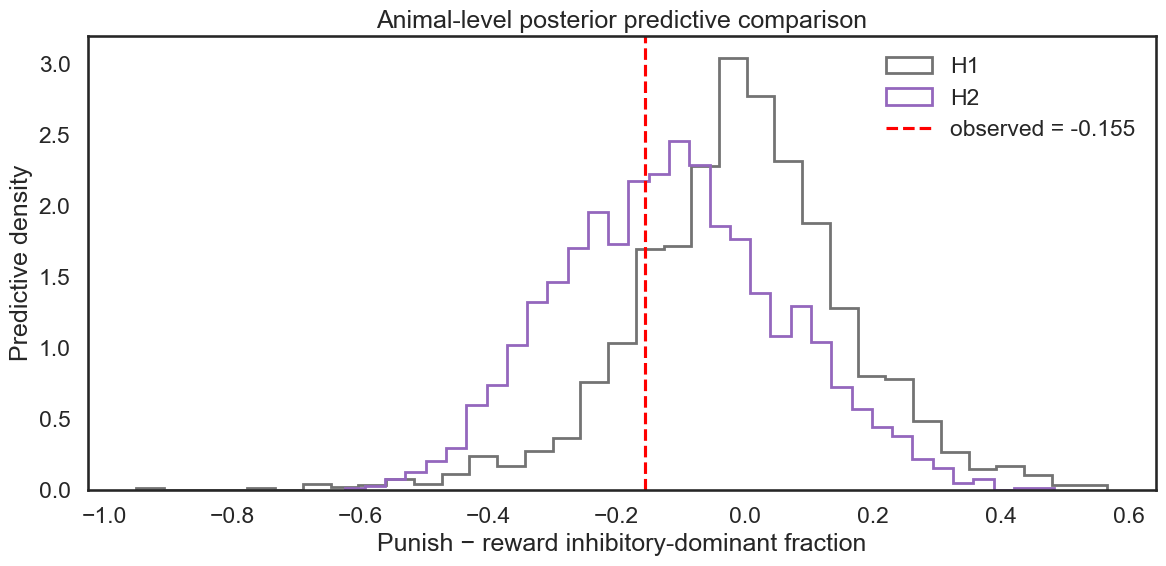

Leave-one-animal-out delta ELPD (H2 − H1): -8.44
Because hotspots are not paired across conditions, H2 here tests condition-specific population sign composition. Directional per-hotspot transition probabilities are not identifiable without pairing or an additional directional constraint.


In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
for simulations, label, color in (
    (h1_ppc, "H1", "0.45"),
    (h2_ppc, "H2", "tab:purple"),
):
    delta = (
        simulations[("punish", "p_inhibitory")]
        - simulations[("reward", "p_inhibitory")]
    )
    ax.hist(
        delta,
        bins=35,
        density=True,
        histtype="step",
        linewidth=2,
        color=color,
        label=label,
    )
ax.axvline(
    observed_delta_p,
    color="red",
    linestyle="--",
    label=f"observed = {observed_delta_p:+.3f}",
)
ax.set_xlabel("Punish − reward inhibitory-dominant fraction")
ax.set_ylabel("Predictive density")
ax.set_title("Animal-level posterior predictive comparison")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

if loao_is_estimable:
    print(
        "Leave-one-animal-out delta ELPD (H2 − H1): "
        f"{h2_elpd - h1_elpd:+.2f}"
    )
print(
    "Because hotspots are not paired across conditions, H2 here tests "
    "condition-specific population sign composition. Directional per-hotspot "
    "transition probabilities are not identifiable without pairing or an "
    "additional directional constraint."
)
